# AML Transaction Analysis → Credit-Dataset Transaction Generator

This notebook consolidates everything from our conversation into one pipeline:

1. **Memory-efficient AML analysis** — stream `LI-Medium_Trans.csv` in chunks (instead of loading
   31M rows at once), with dtypes downcast and dict-based lookups instead of merges.
2. **US-banks-only filter** — restrict both the accounts table and the streamed transactions to
   US banks (non-US banks are named `"<Country> Bank #<id>"`, e.g. `"China Bank #10"`).
3. **Correlation & distribution analysis** — Amount Paid/Received/Is Laundering correlations,
   transactions-per-account distribution, accounts/banks-per-entity vs. transaction volume.
4. **Average-transactions-per-account-count relationship** — fit *per entity type*
   (`Individual` vs `Sole Proprietorship`), since that's what step 5 needs.
5. **Transaction generator for the credit-score dataset** — for each customer in
   `train.csv`, use their `Num_Bank_Accounts` and `Occupation` to simulate a realistic number of
   transactions (and the transactions themselves), borrowing the account→transaction relationship
   learned from the AML data. `Occupation` unknown or `Entrepreneur` → modeled as a
   `Sole Proprietorship`; everything else → modeled as an `Individual`.

Adjust `CHUNKSIZE` in Part 1 if you still hit RAM limits, and adjust `train_data_path` in Part 2
to wherever your credit-score `train.csv` lives.


# Part 1 — AML dataset: memory-efficient loading & analysis

In [77]:
import gc
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def ram_gb():
    return psutil.virtual_memory().available / 1e9

print(f"RAM available: {ram_gb():.2f} GB")

RAM available: 1.41 GB


## 1.1 Download data

In [78]:
import kagglehub

path = kagglehub.dataset_download(
    "ealtman2019/ibm-transactions-for-anti-money-laundering-aml",
    path="LI-Small_Trans.csv",
    output_dir=r"../data/aml"
)
path1 = kagglehub.dataset_download(
    "ealtman2019/ibm-transactions-for-anti-money-laundering-aml",
    path="LI-Small_accounts.csv",
    output_dir=r"../data/aml"
)
print(path)
print(path1)

100%|███████████████████████████████████████████████████████████████████████████████| 620M/620M [09:08<00:00, 1.18MB/s]


100%|█████████████████████████████████████████████████████████████████████████████| 45.1M/45.1M [00:33<00:00, 1.41MB/s]

../data/aml\LI-Small_Trans.csv
../data/aml\LI-Small_accounts.csv


## 1.2 Load `accounts.csv` and keep US banks only

`accounts.csv` is small (~2M rows) so it's safe to load in full. Non-US banks follow the pattern
`"<Country> Bank #<number>"` (e.g. `"China Bank #10"`) — US banks don't have that country prefix,
so we filter on that.

In [2]:
accounts = pd.read_csv(
    "../data/aml/LI-Large_accounts.csv",
    dtype={
        "Bank Name": "category",
        "Bank ID": "int32",
        "Account Number": "string",
        "Entity ID": "category",
        "Entity Name": "string",
    },
)

# Entity "type" is embedded in Entity Name, e.g. "Corporation #41344"
accounts["Entity Type"] = accounts["Entity Name"].str.extract(r"^([A-Za-z ]+) #").astype("category")

# ---- US-banks-only filter ----
foreign_pattern = r"^[A-Za-z ]+ Bank #\d+$"
accounts["Is_Foreign_Bank"] = accounts["Bank Name"].str.match(foreign_pattern)

us_bank_ids = set(accounts.loc[~accounts["Is_Foreign_Bank"], "Bank ID"].unique())
print("US banks:", len(us_bank_ids), "/ Total banks:", accounts["Bank ID"].nunique())

accounts_us = accounts[accounts["Bank ID"].isin(us_bank_ids)].copy()

print("Unique US accounts:", accounts_us["Account Number"].nunique())
print("Unique US entities:", accounts_us["Entity ID"].nunique())
print("\nEntity type distribution (US banks only):")
print(accounts_us["Entity Type"].value_counts())

US banks: 43450 / Total banks: 119619
Unique US accounts: 790450
Unique US entities: 287250

Entity type distribution (US banks only):
Entity Type
Partnership            293678
Sole Proprietorship    269695
Corporation            231207
Individual               1685
Direct                    333
Country                    16
Name: count, dtype: int64


In [43]:
accounts_m = pd.read_csv(
    "../data/aml/LI-Medium_accounts.csv",
    dtype={
        "Bank Name": "category",
        "Bank ID": "int32",
        "Account Number": "string",
        "Entity ID": "category",
        "Entity Name": "string",
    },
)

# Entity "type" is embedded in Entity Name, e.g. "Corporation #41344"
accounts_m["Entity Type"] = accounts_m["Entity Name"].str.extract(r"^([A-Za-z ]+) #").astype("category")

# ---- US-banks-only filter ----
foreign_pattern = r"^[A-Za-z ]+ Bank #\d+$"
accounts_m["Is_Foreign_Bank"] = accounts_m["Bank Name"].str.match(foreign_pattern)

us_bank_ids_m = set(accounts_m.loc[~accounts_m["Is_Foreign_Bank"], "Bank ID"].unique())
print("US banks:", len(us_bank_ids_m), "/ Total banks:", accounts_m["Bank ID"].nunique())

accounts_us_m = accounts_m[accounts_m["Bank ID"].isin(us_bank_ids_m)].copy()

print("Unique US accounts:", accounts_us_m["Account Number"].nunique())
print("Unique US entities:", accounts_us_m["Entity ID"].nunique())
print("\nEntity type distribution (US banks only):")
print(accounts_us_m["Entity Type"].value_counts())

US banks: 43449 / Total banks: 119617
Unique US accounts: 781632
Unique US entities: 286280

Entity type distribution (US banks only):
Entity Type
Partnership            287610
Sole Proprietorship    265752
Corporation            226361
Individual               1667
Direct                    230
Country                    18
Name: count, dtype: int64


In [49]:
# 1. Filter both dataframes to only look at rows where the entity type is "Individual"
indiv_df1 = accounts[accounts['Entity Type'] == 'Individual']
indiv_df2 = accounts_m[accounts_m['Entity Type'] == 'Individual']

# 2. Extract the unique Entity_IDs from these filtered sets
ids_df1 = set(indiv_df1['Entity ID'])
ids_df2 = set(indiv_df2['Entity ID'])

# 3. Check if they have the exact same set of Individual IDs
are_identical = ids_df1 == ids_df2
print(f"Do both dataframes share the exact same 'Individual' Entity_IDs? {are_identical}")

# 4. Optional: See if any "Individual" IDs exist in one dataframe but are missing in the other
if not are_identical:
    print("IDs missing in df2:", ids_df1 - ids_df2)
    print("IDs missing in df1:", ids_df2 - ids_df1)

Do both dataframes share the exact same 'Individual' Entity_IDs? False
IDs missing in df2: {'2AA22ED99E0', '2AA22A300C0', '2AA2265CFC0', '2AA21C16460', '2AA2199BCF0', '2AA228B8D50', '2AA1F3C8780', '2AA2195ED10', '2AA225AEC80', '2AA1F5E6460', '2AA226C6DB0', '2AA2194AC30', '2AA21D54BA0', '2AA2187A4D0', '2AA22745930', '2AA22A6E080', '2AA20E78C30', '2AA21BA6B00', '2AA220B0F00', '2AA22991760', '2AA22F1C6C0', '2AA227A2450', '2AA2193E0F0', '2AA2211A120', '2AA21B89F40', '2AA229D63F0', '2AA22804DE0', '2AA22EC98C0', '2AA2280BB60', '2AA227E5060', '2AA227137B0', '2AA227A6CB0', '2AA209BB600', '2AA22B90590', '2AA223443B0', '2AA21C69C40', '2AA22439C50', '2AA20D705B0', '2AA1F7388A0', '2AA22698700', '2AA22783770', '2AA1F2DA180', '2AA22D1BCA0', '2AA226BB520', '2AA22BD5950', '2AA22343150', '2AA22A70DA0', '2AA22EC8CC0', '2AA22267870', '2AA22EF85E0', '2AA2261CB20', '2AA22E85D20', '2AA20D99EB0', '2AA1F63DB60', '2AA21EBE760', '2AA21C5BA00', '2AA22041AF0', '2AA21B69B30', '2AA227913F0', '2AA20CCD870', '2AA21F1

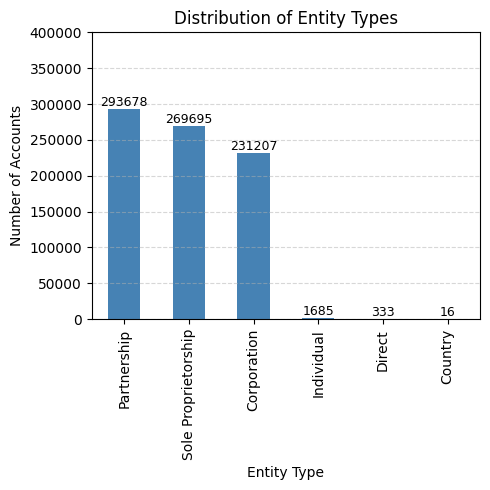

In [3]:
import matplotlib.pyplot as plt

entity_counts = accounts_us["Entity Type"].value_counts()

ax = entity_counts.plot(kind="bar", figsize=(5, 5), color="steelblue")

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

ax.set_title("Distribution of Entity Types")
ax.set_xlabel("Entity Type")
ax.set_ylabel("Number of Accounts")

plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim(top=400000)

plt.tight_layout()
plt.show()

Accounts per entity — summary stats:
count    287250.000000
mean          2.773243
std           5.177014
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         323.000000
Name: Account Number, dtype: float64


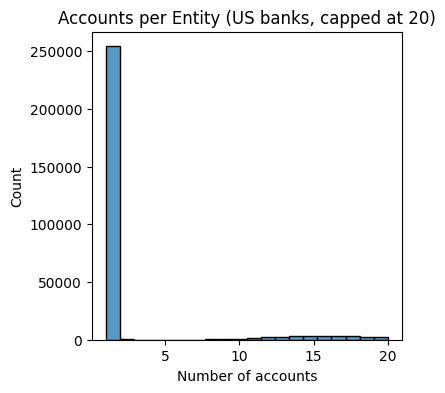


Accounts per bank — summary stats:
count    43450.000000
mean        18.334039
std         81.335700
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max       3424.000000
Name: Account Number, dtype: float64

Entities operating across multiple (US) banks: 32972 out of 287250


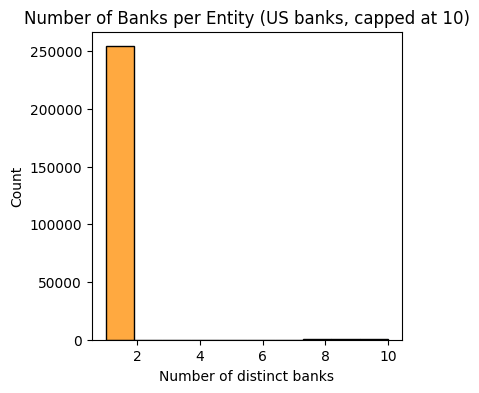

In [4]:
# ---- How many bank accounts does an entity have? ----
accts_per_entity = accounts_us.groupby("Entity ID", observed=True)["Account Number"].count()
print("Accounts per entity — summary stats:")
print(accts_per_entity.describe())

fig, ax = plt.subplots(figsize=(4, 4))
sns.histplot(accts_per_entity[accts_per_entity <= 20], bins=20, ax=ax)
ax.set_title("Accounts per Entity (US banks, capped at 20)")
ax.set_xlabel("Number of accounts")
plt.show()

# ---- Accounts per bank ----
accts_per_bank = accounts_us.groupby("Bank ID", observed=True)["Account Number"].count()
print("\nAccounts per bank — summary stats:")
print(accts_per_bank.describe())

# ---- How many banks does an entity span? ----
banks_per_entity = accounts_us.groupby("Entity ID", observed=True)["Bank ID"].nunique()
print("\nEntities operating across multiple (US) banks:",
      (banks_per_entity > 1).sum(), "out of", len(banks_per_entity))

fig, ax = plt.subplots(figsize=(4, 4))
sns.histplot(banks_per_entity[banks_per_entity <= 10], bins=10, ax=ax, color="darkorange")
ax.set_title("Number of Banks per Entity (US banks, capped at 10)")
ax.set_xlabel("Number of distinct banks")
plt.show()

In [5]:
# ---- Lightweight lookup dicts (used instead of merging the huge transactions table) ----
acct2entity = dict(zip(accounts_us["Account Number"], accounts_us["Entity ID"]))
acct2etype  = dict(zip(accounts_us["Account Number"], accounts_us["Entity Type"]))

print(f"RAM available after building lookup dicts: {ram_gb():.2f} GB")

RAM available after building lookup dicts: 0.62 GB


## 1.3 Stream through `Trans.csv` in chunks (US-to-US transactions only)

Same single-pass accumulation approach as before, with an added filter so only transactions
where **both** the sending and receiving bank are US banks are counted. Switch `&` to `|` below
if you want transactions touching a US bank on *either* side instead of strictly domestic ones.

In [6]:
CHUNKSIZE = 2_000_000  # lower this (e.g. 500_000) if you still run out of RAM

usecols = ["Timestamp", "From Bank", "Account", "To Bank", "Account.1",
           "Amount Received", "Receiving Currency", "Amount Paid",
           "Payment Currency", "Payment Format", "Is Laundering"]

dtype_map = {
    "From Bank": "int32",
    "To Bank": "int32",
    "Amount Received": "float32",
    "Amount Paid": "float32",
    "Receiving Currency": "category",
    "Payment Currency": "category",
    "Payment Format": "category",
    "Is Laundering": "int8",
}

# ---------- accumulators  ----------
out_degree = Counter()
in_degree = Counter()
bank_out_count = Counter()
bank_in_count = Counter()
entity_txn_count = Counter()
entity_type_count = Counter()
entity_type_launder_sum = Counter()

currency_pay_counts = Counter()
currency_recv_counts = Counter()
format_counts = Counter()
format_launder_sum = Counter()

daily_counts = Counter()
hourly_counts = Counter()
hourly_launder_sum = Counter()

same_bank_launder = Counter()
cross_currency_launder = Counter()
same_entity_launder = Counter()

n_rows = 0
s_paid = s_recv = s_laund = 0.0
sq_paid = sq_recv = sq_laund = 0.0
xy_paid_recv = xy_paid_laund = xy_recv_laund = 0.0

duplicate_rows = 0
ts_min, ts_max = None, None

reader = pd.read_csv("../data/aml/LI-Large_Trans.csv", usecols=usecols, dtype=dtype_map, chunksize=CHUNKSIZE)

for i, chunk in enumerate(reader):
    # ---- US-banks-only filter ----
    chunk = chunk[chunk["From Bank"].isin(us_bank_ids) & chunk["To Bank"].isin(us_bank_ids)]
    n = len(chunk)
    if n == 0:
        continue
    n_rows += n

    duplicate_rows += chunk.duplicated().sum()

    ts = pd.to_datetime(chunk["Timestamp"], format="%Y/%m/%d %H:%M")
    ts_min = ts.min() if ts_min is None else min(ts_min, ts.min())
    ts_max = ts.max() if ts_max is None else max(ts_max, ts.max())
    hours = ts.dt.hour
    dates = ts.dt.date

    hourly_counts.update(hours.value_counts().to_dict())
    daily_counts.update(pd.Series(dates).value_counts().to_dict())
    hourly_launder_sum.update(chunk.groupby(hours, observed=True)["Is Laundering"].sum().to_dict())

    paid = chunk["Amount Paid"].astype("float64")
    recv = chunk["Amount Received"].astype("float64")
    laund = chunk["Is Laundering"].astype("float64")

    s_paid += paid.sum();  sq_paid += (paid ** 2).sum()
    s_recv += recv.sum();  sq_recv += (recv ** 2).sum()
    s_laund += laund.sum(); sq_laund += (laund ** 2).sum()
    xy_paid_recv  += (paid * recv).sum()
    xy_paid_laund += (paid * laund).sum()
    xy_recv_laund += (recv * laund).sum()

    out_degree.update(chunk["Account"].value_counts().to_dict())
    in_degree.update(chunk["Account.1"].value_counts().to_dict())

    bank_out_count.update(chunk["From Bank"].value_counts().to_dict())
    bank_in_count.update(chunk["To Bank"].value_counts().to_dict())

    currency_pay_counts.update(chunk["Payment Currency"].value_counts().to_dict())
    currency_recv_counts.update(chunk["Receiving Currency"].value_counts().to_dict())
    format_counts.update(chunk["Payment Format"].value_counts().to_dict())
    format_launder_sum.update(chunk.groupby(chunk["Payment Format"], observed=True)["Is Laundering"].sum().to_dict())

    same_bank = chunk["From Bank"] == chunk["To Bank"]
    cross_curr = chunk["Payment Currency"].astype(str) != chunk["Receiving Currency"].astype(str)

    same_bank_launder.update(chunk.groupby([same_bank, chunk["Is Laundering"]]).size().to_dict())
    cross_currency_launder.update(chunk.groupby([cross_curr, chunk["Is Laundering"]]).size().to_dict())

    sender_entity = chunk["Account"].map(acct2entity)
    receiver_entity = chunk["Account.1"].map(acct2entity)
    sender_etype = chunk["Account"].map(acct2etype)

    same_entity = sender_entity == receiver_entity
    same_entity_launder.update(chunk.groupby([same_entity, chunk["Is Laundering"]]).size().to_dict())

    entity_type_count.update(sender_etype.value_counts(dropna=True).to_dict())
    entity_type_launder_sum.update(
        chunk.groupby(sender_etype, observed=True)["Is Laundering"].sum().to_dict()
    )

    entity_txn_count.update(sender_entity.dropna().value_counts().to_dict())
    entity_txn_count.update(receiver_entity.dropna().value_counts().to_dict())

    del chunk, ts, hours, dates, paid, recv, laund, same_bank, cross_curr
    del sender_entity, receiver_entity, sender_etype, same_entity
    if i % 3 == 0:
        gc.collect()
        print(f"  processed {n_rows:,} US-to-US rows so far | RAM available: {ram_gb():.2f} GB")

print(f"\nDone. Total US-to-US rows processed: {n_rows:,}")
print("Duplicate rows:", duplicate_rows)
print("Date range:", ts_min, "to", ts_max)

  processed 761,149 US-to-US rows so far | RAM available: 0.63 GB
  processed 3,012,776 US-to-US rows so far | RAM available: 0.79 GB
  processed 5,258,190 US-to-US rows so far | RAM available: 1.10 GB
  processed 7,503,577 US-to-US rows so far | RAM available: 1.05 GB
  processed 9,747,825 US-to-US rows so far | RAM available: 1.21 GB
  processed 11,993,491 US-to-US rows so far | RAM available: 1.20 GB
  processed 14,239,534 US-to-US rows so far | RAM available: 1.24 GB
  processed 16,487,797 US-to-US rows so far | RAM available: 1.22 GB
  processed 18,733,579 US-to-US rows so far | RAM available: 1.28 GB
  processed 21,176,895 US-to-US rows so far | RAM available: 1.23 GB
  processed 23,240,036 US-to-US rows so far | RAM available: 1.24 GB
  processed 25,487,398 US-to-US rows so far | RAM available: 1.31 GB
  processed 27,741,850 US-to-US rows so far | RAM available: 1.33 GB
  processed 29,983,623 US-to-US rows so far | RAM available: 1.24 GB
  processed 32,230,272 US-to-US rows so f

## 1.4 Class balance, amounts, currency & payment-format breakdowns

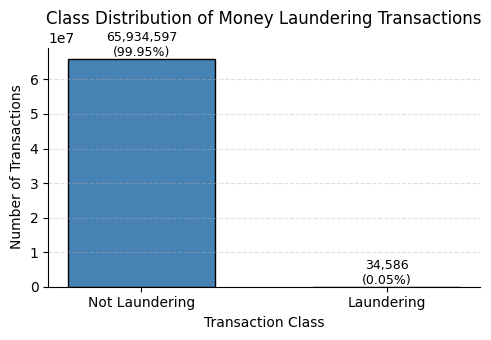

In [7]:
# Create class distribution
is_laundering_count = pd.Series({ 0: n_rows - int(s_laund),1: int(s_laund)})
is_laundering_pct = (is_laundering_count / n_rows) * 100

# Plot
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(
    ["Not Laundering", "Laundering"],
    is_laundering_count.values,
    color=["steelblue", "indianred"],
    edgecolor="black",
    width=0.6
)
for bar, count, pct in zip(
    bars,
    is_laundering_count.values,
    is_laundering_pct.values
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )
# Formatting
ax.set_title("Class Distribution of Money Laundering Transactions")
ax.set_xlabel("Transaction Class")
ax.set_ylabel("Number of Transactions")

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Payment Currency distribution:
US Dollar            65773815
Euro                    83151
Bitcoin                 47114
Yuan                    29630
Saudi Riyal             18183
Yen                      9984
Ruble                    4383
Rupee                    2923
Mexican Peso                0
Australian Dollar           0
Canadian Dollar             0
UK Pound                    0
Swiss Franc                 0
Brazil Real                 0
Shekel                      0
dtype: int64

Payment Format distribution:
Cheque          26281901
Credit Card     18938133
ACH              8600867
Cash             6854982
Reinvestment     2858019
Wire             2388167
Bitcoin            47114
dtype: int64


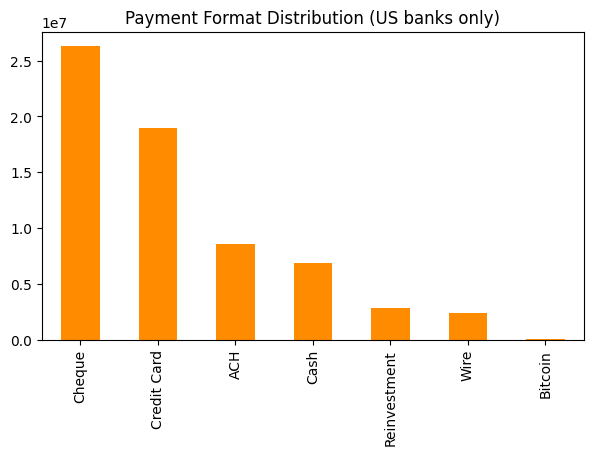


Laundering rate by Payment Format:
ACH             0.002916
Cheque          0.000194
Cash            0.000193
Credit Card     0.000163
Bitcoin         0.000000
Reinvestment    0.000000
Wire            0.000000
dtype: float64


In [8]:
print("Payment Currency distribution:")
print(pd.Series(currency_pay_counts).sort_values(ascending=False))

print("\nPayment Format distribution:")
format_s = pd.Series(format_counts).sort_values(ascending=False)
print(format_s)

fig, ax = plt.subplots(figsize=(7, 4))
format_s.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Payment Format Distribution (US banks only)")
plt.show()

fmt_rate = (pd.Series(format_launder_sum) / pd.Series(format_counts)).sort_values(ascending=False)
print("\nLaundering rate by Payment Format:")
print(fmt_rate)

Share of intra-bank transactions: 0.06783944861042163
                  0         1
Same_Bank                    
False      0.999439  0.000561
True       0.999974  0.000026


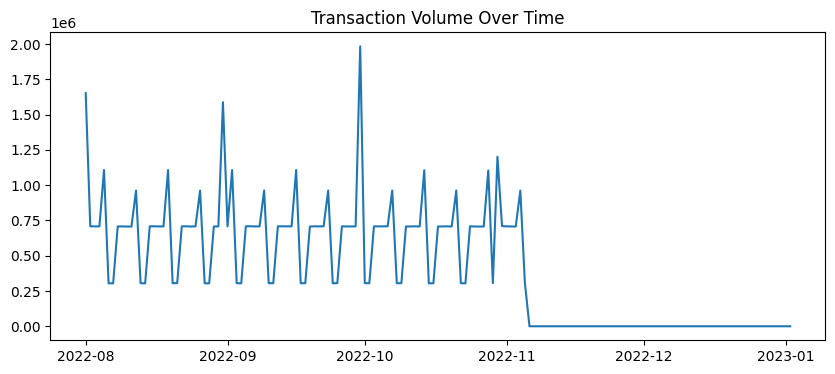

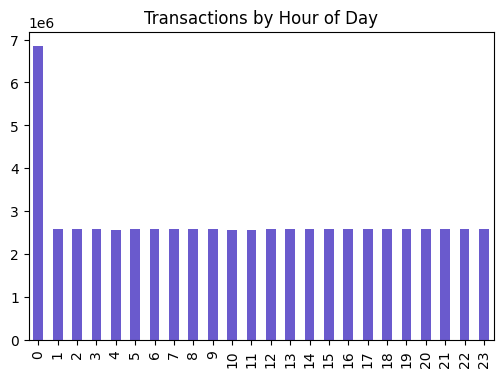

In [9]:
sb = pd.Series(same_bank_launder).unstack(fill_value=0)
sb.index.name = "Same_Bank"
print("Share of intra-bank transactions:",
      sb.loc[True].sum() / (sb.loc[True].sum() + sb.loc[False].sum()))
print((sb.T / sb.sum(axis=1)).T)

daily_s = pd.Series(daily_counts).sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
daily_s.plot(ax=ax)
ax.set_title("Transaction Volume Over Time")
plt.show()

hourly_s = pd.Series(hourly_counts).sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
hourly_s.plot(kind="bar", ax=ax, color="slateblue")
ax.set_title("Transactions by Hour of Day")
plt.show()

## 1.5 Correlation matrix (Amount Paid / Amount Received / Is Laundering)

                 Amount Paid  Amount Received  Is Laundering
Amount Paid         1.000000     2.415438e-01   1.325141e-03
Amount Received     0.241544     1.000000e+00   9.766841e-07
Is Laundering       0.001325     9.766841e-07   1.000000e+00


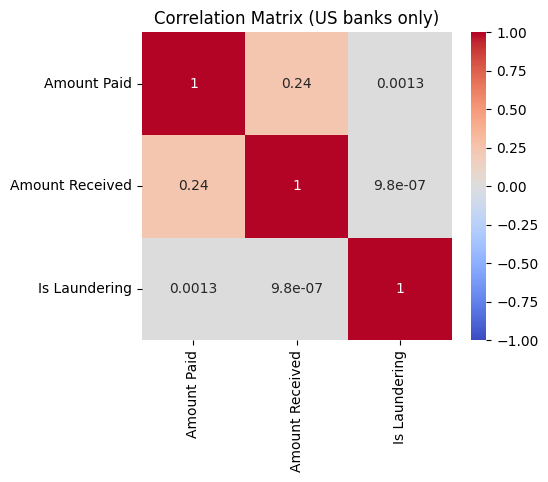


Mean Amount Paid:     337,659.38
Mean Amount Received: 6,184,886.42


In [10]:
def pearson(sx, sqx, sy, sqy, sxy, n):
    cov = n * sxy - sx * sy
    var_x = n * sqx - sx ** 2
    var_y = n * sqy - sy ** 2
    return cov / np.sqrt(var_x * var_y)

r_paid_recv  = pearson(s_paid, sq_paid, s_recv, sq_recv, xy_paid_recv, n_rows)
r_paid_laund = pearson(s_paid, sq_paid, s_laund, sq_laund, xy_paid_laund, n_rows)
r_recv_laund = pearson(s_recv, sq_recv, s_laund, sq_laund, xy_recv_laund, n_rows)

corr_matrix = pd.DataFrame(
    [[1.0, r_paid_recv, r_paid_laund],
     [r_paid_recv, 1.0, r_recv_laund],
     [r_paid_laund, r_recv_laund, 1.0]],
    index=["Amount Paid", "Amount Received", "Is Laundering"],
    columns=["Amount Paid", "Amount Received", "Is Laundering"],
)
print(corr_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix (US banks only)")
plt.show()

mean_amount = s_paid / n_rows
print(f"\nMean Amount Paid:     {mean_amount:,.2f}")
print(f"Mean Amount Received: {s_recv/n_rows:,.2f}")

## 1.6 Distribution of transactions per bank account (fan-in / fan-out)

Sending activity per account — summary:
count    7.776210e+05
mean     8.483462e+01
std      7.177783e+03
min      1.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      2.100000e+01
max      6.327667e+06
Name: out_degree, dtype: float64

Receiving activity per account — summary:
count    645126.000000
mean        102.257827
std         131.751986
min           1.000000
25%           7.000000
50%          25.000000
75%         196.000000
max       31734.000000
Name: in_degree, dtype: float64

Total transactions per account — summary:
count    7.894720e+05
mean     1.671223e+02
std      7.161335e+03
min      1.000000e+00
25%      1.400000e+01
50%      3.200000e+01
75%      2.290000e+02
max      6.359401e+06
dtype: float64


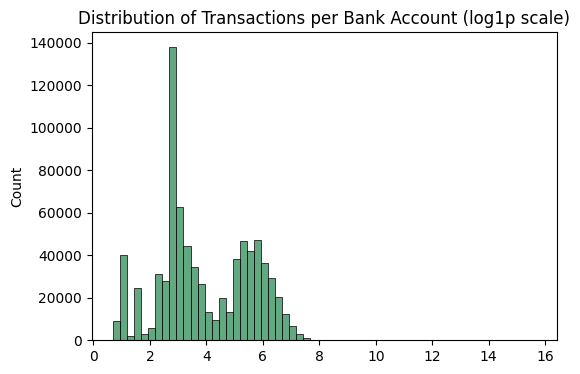

In [11]:
out_degree_s = pd.Series(out_degree, name="out_degree")
in_degree_s = pd.Series(in_degree, name="in_degree")

print("Sending activity per account — summary:")
print(out_degree_s.describe())
print("\nReceiving activity per account — summary:")
print(in_degree_s.describe())

total_degree = out_degree_s.add(in_degree_s, fill_value=0)
print("\nTotal transactions per account — summary:")
print(total_degree.describe())

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(np.log1p(total_degree), bins=60, ax=ax, color="seagreen")
ax.set_title("Distribution of Transactions per Bank Account (log1p scale)")
plt.show()

## 1.7 Entities: accounts, banks, and transaction volume — correlation & distribution

Per-entity summary (accounts / transactions):
          n_accounts  n_transactions
count  287250.000000    2.872500e+05
mean        2.773243    4.593155e+02
std         5.177014    1.187319e+04
min         1.000000    0.000000e+00
25%         1.000000    1.770000e+02
50%         1.000000    3.210000e+02
75%         1.000000    5.730000e+02
max       323.000000    6.360010e+06

Correlation between # accounts and # transactions per entity:
                n_accounts  n_transactions
n_accounts        1.000000        0.024255
n_transactions    0.024255        1.000000


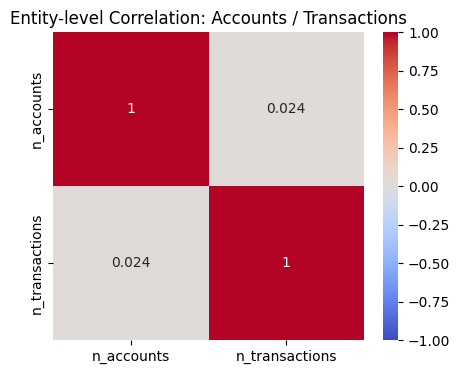

In [12]:
entity_txn_s = pd.Series(entity_txn_count, name="n_transactions")

df_entity = pd.DataFrame({
    "n_accounts": accts_per_entity,
}).join(entity_txn_s, how="left").fillna({"n_transactions": 0})

print("Per-entity summary (accounts / transactions):")
print(df_entity.describe())

print("\nCorrelation between # accounts and # transactions per entity:")
print(df_entity.corr())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df_entity.corr(), annot=True, cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Entity-level Correlation: Accounts / Transactions")
plt.show()

## 1.8 Average transactions per entity, by number of accounts held

Answers: *"if a person has n bank accounts, on average how many transactions do they do?"*

                   mean  median   count
n_accounts                             
1            357.105538   288.0  254137
2            370.346667    24.0     225
3            950.520000    40.5      50
4            167.235294    56.0      17
5            295.818182   219.0      44
6            379.828125   306.5      64
7            441.384615   343.0     143
8            530.075710   465.0     317
9            573.159091   492.0     572
10           638.463705   573.0     923
11           723.783685   633.0    1373
12           768.637904   686.0    1947
13           838.819162   753.0    2411
14          3047.149561   816.0    2962
15           959.138123   900.5    3048
16          1021.784674   942.0    3158
17          1090.742448  1013.0    3211
18          1145.563063  1068.0    2886
19          1210.204371  1132.0    2471
20          1294.031584  1201.5    2058

On average, each extra bank account adds ~55.63 transactions (baseline ~305.05 txns with 1 account)


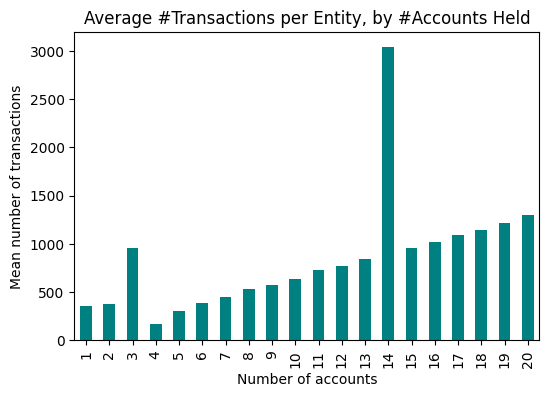

In [13]:
avg_txn_by_naccounts = df_entity.groupby("n_accounts")["n_transactions"].agg(["mean", "median", "count"])
print(avg_txn_by_naccounts.head(20))

slope, intercept = np.polyfit(df_entity["n_accounts"], df_entity["n_transactions"], 1)
print(f"\nOn average, each extra bank account adds ~{slope:.2f} transactions "
      f"(baseline ~{intercept:.2f} txns with 1 account)")

fig, ax = plt.subplots(figsize=(6, 4))
avg_txn_by_naccounts["mean"][avg_txn_by_naccounts["mean"].index <= 20].plot(kind="bar", ax=ax, color="teal")
ax.set_title("Average #Transactions per Entity, by #Accounts Held")
ax.set_xlabel("Number of accounts"); ax.set_ylabel("Mean number of transactions")
plt.show()

## 1.9 Same-entity transfers & laundering rate by entity type

In [14]:
se = pd.Series(same_entity_launder).unstack(fill_value=0)
se.index.name = "Same_Entity_Transfer"
print("Same-entity transfer rate:",
      se.loc[True].sum() / (se.loc[True].sum() + se.loc[False].sum()))
print((se.T / se.sum(axis=1)).T)

etype_rate = (pd.Series(entity_type_launder_sum) / pd.Series(entity_type_count)).sort_values(ascending=False)
print("\nLaundering rate by Sender Entity Type:")
print(etype_rate)

Same-entity transfer rate: 0.06482682982446517
                             0         1
Same_Entity_Transfer                    
False                 0.999440  0.000560
True                  0.999997  0.000003

Laundering rate by Sender Entity Type:
Corporation            0.000762
Partnership            0.000598
Individual             0.000531
Sole Proprietorship    0.000242
Country                0.000000
Direct                 0.000000
dtype: float64


### Part 2

In [30]:
# ---- attach entity type to df_entity (if not already done) ----
etype_map = accounts_us.drop_duplicates("Entity ID").set_index("Entity ID")["Entity Type"]
df_entity["Entity Type"] = df_entity.index.map(etype_map)

# cap n_accounts for a readable table (long tail beyond ~15 accounts is sparse)
df_entity["n_accounts_capped"] = df_entity["n_accounts"].clip(upper=20).astype(int)

txn_distribution = (
    df_entity.groupby(["n_accounts_capped", "Entity Type"], observed=True)["n_transactions"]
    .agg(n_entities="count", mean_txn="mean", median_txn="median",
         std_txn="std", min_txn="min", max_txn="max", total_txn="sum")
    .reset_index()
    .sort_values(["Entity Type", "n_accounts_capped"])
    .reset_index(drop=True)
)
df_entity.head()

,n_accounts,n_transactions,Entity Type,n_accounts_capped
Entity ID,,,,
2AA1F2B5B30,1,1499.0,Sole Proprietorship,1
2AA1F2B5B90,1,2350.0,Sole Proprietorship,1
2AA1F2B6310,1,1488.0,Corporation,1
2AA1F2B7210,1,1685.0,Sole Proprietorship,1
2AA1F2B7FF0,1,760.0,Corporation,1


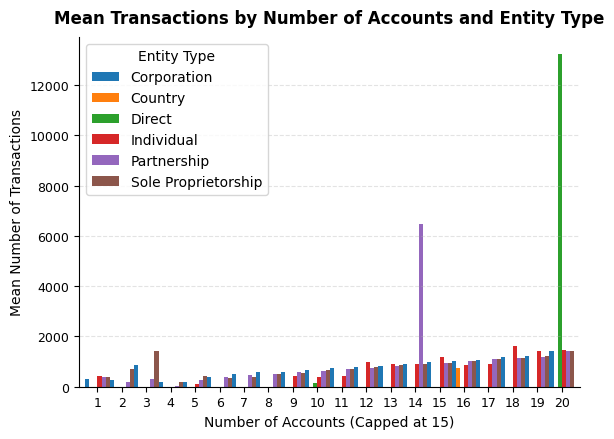

In [17]:
fig, ax = plt.subplots(figsize=(6, 4.5))
pivot = txn_distribution.pivot(index="n_accounts_capped",columns="Entity Type",values="mean_txn")
pivot.plot(kind="bar",ax=ax,width=1)
ax.set_title("Mean Transactions by Number of Accounts and Entity Type",fontsize=12,weight="bold",pad=10)
ax.set_xlabel("Number of Accounts (Capped at 15)", fontsize=10)
ax.set_ylabel("Mean Number of Transactions", fontsize=10)
ax.grid(axis="y",linestyle="--",alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [36]:
MAX_ENTITIES_PER_BUCKET = 1000  # cap per (n_accounts, entity_type) bucket for memory

df_entity_valid = df_entity[df_entity["n_transactions"] > 0].copy()

entity_pool = {}  # (n_accounts, entity_type) -> [entity_id, ...]
rng_pool = np.random.default_rng(7)
for (n_acc, etype), grp in df_entity_valid.groupby(["n_accounts", "Entity Type"], observed=True):
    ids = grp.index.to_numpy()
    if len(ids) > MAX_ENTITIES_PER_BUCKET:
        ids = rng_pool.choice(ids, size=MAX_ENTITIES_PER_BUCKET, replace=False)
    entity_pool[(n_acc, etype)] = list(ids)

available_buckets = pd.DataFrame(
    [(k[0], k[1], len(v)) for k, v in entity_pool.items()],
    columns=["n_accounts", "Entity Type", "n_candidate_entities"]
).sort_values(["Entity Type", "n_accounts"])


needed_entity_ids = {e for ids in entity_pool.values() for e in ids}
needed_accounts = set(accounts_us.loc[accounts_us["Entity ID"].isin(needed_entity_ids), "Account Number"])
print(f"Entities needed: {len(needed_entity_ids):,} | Accounts to track: {len(needed_accounts):,}")

ind = available_buckets[available_buckets["Entity Type"] == "Individual"]
print(ind)

Entities needed: 34,917 | Accounts to track: 520,357
     n_accounts Entity Type  n_candidate_entities
1             1  Individual                    41
14            5  Individual                     1
27            9  Individual                     3
32           10  Individual                     1
36           11  Individual                     3
40           12  Individual                     8
44           13  Individual                     9
48           14  Individual                    14
52           15  Individual                     8
57           16  Individual                    14
61           17  Individual                    11
65           18  Individual                     5
69           19  Individual                     4
73           20  Individual                     4
77           21  Individual                     7
81           22  Individual                     4
85           23  Individual                     2
89           24  Individual                    

In [19]:
captured_frames = []
reader2 = pd.read_csv("../data/aml/LI-Large_Trans.csv", usecols=usecols, dtype=dtype_map, chunksize=CHUNKSIZE)
for i, chunk in enumerate(reader2):
    chunk = chunk[chunk["From Bank"].isin(us_bank_ids) & chunk["To Bank"].isin(us_bank_ids)]
    if len(chunk) == 0:
        continue

    sender_mask = chunk["Account"].isin(needed_accounts)
    receiver_mask = chunk["Account.1"].isin(needed_accounts)
    row_mask = sender_mask | receiver_mask
    if not row_mask.any():
        continue

    sub = chunk[row_mask]
    sender_mask = sender_mask[row_mask]
    receiver_mask = receiver_mask[row_mask]

    parts = []
    if sender_mask.any():
        s = sub[sender_mask]
        parts.append(pd.DataFrame({
            **{c: s[c].values for c in s.columns},
            "_role": "sender",
            "_entity_id": s["Account"].map(acct2entity).values,
        }))
    if receiver_mask.any():
        r = sub[receiver_mask]
        parts.append(pd.DataFrame({
            **{c: r[c].values for c in r.columns},
            "_role": "receiver",
            "_entity_id": r["Account.1"].map(acct2entity).values,
        }))

    if parts:
        captured_frames.append(pd.concat(parts, ignore_index=True))

    del chunk, sub
    if i % 3 == 0:
        gc.collect()
        so_far = sum(len(f) for f in captured_frames)
        print(f"  pass 2: {i} chunks | RAM {ram_gb():.2f} GB | captured rows so far: {so_far:,}")

# ---- single groupby at the end instead of one per chunk ----
all_captured = pd.concat(captured_frames, ignore_index=True).drop_duplicates()
del captured_frames
gc.collect()

entity_transactions = {
    eid: grp.drop(columns="_entity_id").reset_index(drop=True)
    for eid, grp in all_captured.groupby("_entity_id", observed=True)
}
del all_captured
gc.collect()

print(f"Entities with retrieved real transactions: {len(entity_transactions):,}")

  pass 2: 0 chunks | RAM 0.71 GB | captured rows so far: 348,799
  pass 2: 3 chunks | RAM 1.23 GB | captured rows so far: 967,359
  pass 2: 6 chunks | RAM 1.29 GB | captured rows so far: 1,556,588
  pass 2: 9 chunks | RAM 1.45 GB | captured rows so far: 2,068,779
  pass 2: 12 chunks | RAM 1.16 GB | captured rows so far: 2,659,905
  pass 2: 15 chunks | RAM 1.24 GB | captured rows so far: 3,171,597
  pass 2: 18 chunks | RAM 1.30 GB | captured rows so far: 3,762,159
  pass 2: 21 chunks | RAM 1.25 GB | captured rows so far: 4,275,958
  pass 2: 24 chunks | RAM 1.22 GB | captured rows so far: 4,869,087
  pass 2: 27 chunks | RAM 1.14 GB | captured rows so far: 5,666,345
  pass 2: 30 chunks | RAM 1.06 GB | captured rows so far: 6,170,490
  pass 2: 33 chunks | RAM 1.17 GB | captured rows so far: 6,726,212
  pass 2: 36 chunks | RAM 1.31 GB | captured rows so far: 7,280,697
  pass 2: 39 chunks | RAM 1.38 GB | captured rows so far: 7,833,785
  pass 2: 42 chunks | RAM 1.29 GB | captured rows so far

In [20]:
# ================================================================
# Part 4 — Build customer profile (data already cleaned), occupation -> entity type,
#           income lookup, income-matched entity assignment
# ================================================================

# ---- 4.1 Occupation -> entity type mapping ----
def map_occupation(occ):
    if occ == "Entrepreneur":
        return "Sole Proprietorship"
    elif occ == "Unknown":
        return None            # resolved via sampling: "any type of entity"
    else:
        return "Individual"


# ---- 4.2 Collapse cleaned raw rows into one profile per customer ----

def get_most_frequent(series):
    mode_vals = series.mode()
    if not mode_vals.empty:
        return mode_vals.iloc[0]
    return "Unknown"  # fallback if the entire series is empty/NaN


def build_customer_profile(raw_df):
    has_income = "Annual_Income" in raw_df.columns

    agg_cols = ["Occupation", "Num_Bank_Accounts"]
    if has_income:
        agg_cols.append("Annual_Income")

    profile = (
        raw_df.groupby("Customer_ID")[agg_cols]
        .agg(get_most_frequent)
        .reset_index()
    )

    if not has_income:
        profile["Annual_Income"] = np.nan  # keeps downstream code uniform for test set

    profile["Num_Bank_Accounts"] = profile["Num_Bank_Accounts"].round().astype(int)

    # ---- Occupation -> Assumed_Entity_Type ----
    profile["Assumed_Entity_Type"] = profile["Occupation"].apply(map_occupation)

    entity_type_probs = df_entity["Entity Type"].value_counts(normalize=True)
    rng_unknown = np.random.default_rng(11)
    mask = profile["Assumed_Entity_Type"].isna()
    profile.loc[mask, "Assumed_Entity_Type"] = rng_unknown.choice(
        entity_type_probs.index, size=mask.sum(), p=entity_type_probs.values
    )
    return profile

# ---- 4.3 Precompute each candidate entity's estimated income (from its real transactions) ----
DATASET_DAYS = 97  # fixed span per the AML dataset paper

def build_entity_income_lookup(entity_transactions, dataset_days=DATASET_DAYS):
    records = []
    for eid, txns in entity_transactions.items():
        n = len(txns)
        received = txns.loc[txns["_role"] == "receiver", "Amount Received"].sum()
        avg_amount_per_day = received / dataset_days
        annual_income_est = avg_amount_per_day * 365
        records.append((eid, n, received, avg_amount_per_day, annual_income_est))
    return pd.DataFrame(
        records,
        columns=["Entity_ID", "N_Transactions_3mo", "Sum_Received_3mo", "Avg_Amount_Per_Day", "Estimated_Annual_Income"]
    ).set_index("Entity_ID")


entity_income_lookup = build_entity_income_lookup(entity_transactions)
print("Entity income lookup:")
print(entity_income_lookup.describe())


# ---- 4.4 Bucket lookups (n_accounts available per entity type, for nearest-match fallback) ----
avail_by_type = {}
for (n_acc, etype) in entity_pool:
    avail_by_type.setdefault(etype, []).append(n_acc)

def nearest_n_accounts(n_acc, etype):
    opts = avail_by_type.get(etype, [])
    return min(opts, key=lambda x: abs(x - n_acc)) if opts else None


def assign_entities(profile, entity_pool, entity_income_lookup, avail_by_type, seed=2024):
    rng = np.random.default_rng(seed)
    assigned = []
    for row in profile.itertuples(index=False):
        key = (row.Num_Bank_Accounts, row.Assumed_Entity_Type)
        if key not in entity_pool:
            matched_n = nearest_n_accounts(row.Num_Bank_Accounts, row.Assumed_Entity_Type)
            key = (matched_n, row.Assumed_Entity_Type)
        candidates = entity_pool.get(key, [])
        if not candidates:
            assigned.append(None)
            continue

        target_income = row.Annual_Income
        if pd.notna(target_income) and target_income > 0:
            cand_income = entity_income_lookup.reindex(candidates)["Estimated_Annual_Income"].clip(lower=1)
            # ---- log-space distance instead of raw absolute difference ----
            log_target = np.log(target_income)
            log_diff = (np.log(cand_income) - log_target).abs()
            best_eid = log_diff.idxmin()
            assigned.append(best_eid)
        else:
            assigned.append(rng.choice(candidates))
    return assigned

Entity income lookup:
       N_Transactions_3mo  Sum_Received_3mo  Avg_Amount_Per_Day  \
count        17934.000000      1.793400e+04        1.793400e+04   
mean           956.282815      3.283700e+09        3.385258e+07   
std            729.450455      2.794089e+11        2.880500e+09   
min              1.000000      0.000000e+00        0.000000e+00   
25%            456.000000      8.811731e+05        9.084259e+03   
50%            865.000000      4.256382e+06        4.388023e+04   
75%           1331.000000      3.232048e+07        3.332008e+05   
max          36650.000000      3.628101e+13        3.740311e+11   

       Estimated_Annual_Income  
count             1.793400e+04  
mean              1.235619e+10  
std               1.051382e+12  
min               0.000000e+00  
25%               3.315754e+06  
50%               1.601628e+07  
75%               1.216183e+08  
max               1.365213e+14  


In [21]:
# ==========================================================================
# Part 5 — Build customer transactions from assigned entities, derive income
# ==========================================================================

def build_customer_transactions(profile, entity_transactions):
    frames = []
    for row in profile.itertuples(index=False):
        eid = row.Assigned_Entity_ID
        if eid is None or eid not in entity_transactions:
            continue
        txns = entity_transactions[eid].copy()
        txns["Customer_ID"] = row.Customer_ID
        txns["Source_Entity_ID"] = eid
        txns["Assumed_Entity_Type"] = row.Assumed_Entity_Type
        frames.append(txns)
    return pd.concat(frames, ignore_index=True)

def estimate_income(cust_txn_df, dataset_days=DATASET_DAYS):
    def agg(g):
        n = len(g)
        received = g.loc[g["_role"] == "receiver", "Amount Received"].sum()
        avg_amount_per_day = received / dataset_days
        return pd.Series({
            "N_Transactions_3mo": n,
            "Sum_Received_3mo": received,
            "Avg_Amount_Per_Day": avg_amount_per_day,
            "Estimated_Annual_Income": avg_amount_per_day * 365,
        })
    return cust_txn_df.groupby("Customer_ID").apply(agg).reset_index()

def process_split(raw_df, entity_pool, entity_income_lookup, avail_by_type, entity_transactions, seed=2024):
    profile = build_customer_profile(raw_df)
    profile["Assigned_Entity_ID"] = assign_entities(
        profile, entity_pool, entity_income_lookup, avail_by_type, seed
    )
    print(f"  {profile['Assigned_Entity_ID'].isna().sum()} customers had no matching bucket")

    txns = build_customer_transactions(profile, entity_transactions)
    income_df = estimate_income(txns)
    profile = profile.merge(income_df, on="Customer_ID", how="left")
    return profile, txns

# ---- run on train ----
train_df = pd.read_csv("../data/cleaned_credit/cleaned_train.csv", low_memory=False)
print("Processing train split...")
customer_profile, customer_transactions = process_split(
    train_df, entity_pool, entity_income_lookup, avail_by_type, entity_transactions, seed=2024
)
customer_profile.to_csv("../data/simulated/customer_profile_train.csv", index=False)
customer_transactions.to_csv("../data/simulated/customer_transactions_train.csv", index=False)
print(customer_profile.shape, customer_transactions.shape)

# ---- run on test ----
test_df = pd.read_csv("../data/cleaned_credit/cleaned_test.csv", low_memory=False)
print("\nProcessing test split...")
test_profile, test_transactions = process_split(
    test_df, entity_pool, entity_income_lookup, avail_by_type, entity_transactions, seed=4242
)
test_profile.to_csv("../data/simulated/customer_profile_test.csv", index=False)
test_transactions.to_csv("../data/simulated/customer_transactions_test.csv", index=False)
print(test_profile.shape, test_transactions.shape)


# ================================================================
# SANITY CHECKS — full pipeline, on a random sample of customers
# ================================================================

def sanity_check_assignments(profile, entity_transactions, entity_income_lookup, n_samples=8, seed=99, label="train"):
    print(f"\n================ SANITY CHECK: {label} split ================")
    valid = profile.dropna(subset=["Assigned_Entity_ID"])
    if len(valid) == 0:
        print("No valid assignments to check.")
        return
    sample = valid.sample(n=min(n_samples, len(valid)), random_state=seed)

    for row in sample.itertuples(index=False):
        eid = row.Assigned_Entity_ID
        n_customer_txns = row.N_Transactions_3mo if pd.notna(getattr(row, "N_Transactions_3mo", np.nan)) else "N/A"
        n_entity_txns = len(entity_transactions.get(eid, []))
        entity_true_type = df_entity.loc[eid, "Entity Type"] if eid in df_entity.index else "N/A"
        entity_true_naccounts = df_entity.loc[eid, "n_accounts"] if eid in df_entity.index else "N/A"

        print(f"\nCustomer {row.Customer_ID}")
        print(f"  Occupation                 : {row.Occupation}")
        print(f"  Assumed_Entity_Type         : {row.Assumed_Entity_Type}")
        print(f"  Num_Bank_Accounts (customer): {row.Num_Bank_Accounts}")
        print(f"  Assigned_Entity_ID          : {eid}")
        print(f"  Entity's true Entity Type   : {entity_true_type}  "
              f"({'MATCH' if entity_true_type == row.Assumed_Entity_Type else 'MISMATCH'})")
        print(f"  Entity's true n_accounts    : {entity_true_naccounts}")
        print(f"  N_Transactions (customer)   : {n_customer_txns}")
        print(f"  N_Transactions (entity pool): {n_entity_txns}")
        print(f"  Customer Annual_Income      : {row.Annual_Income}")
        print(f"  Customer Estimated_Annual_Income: {getattr(row, 'Estimated_Annual_Income', np.nan)}")
        if eid in entity_income_lookup.index:
            print(f"  Entity's own Estimated_Annual_Income (pre-assignment): "
                  f"{entity_income_lookup.loc[eid, 'Estimated_Annual_Income']:.2f}")

sanity_check_assignments(customer_profile, entity_transactions, entity_income_lookup, n_samples=8, label="train")
sanity_check_assignments(test_profile, entity_transactions, entity_income_lookup, n_samples=8, label="test")


# ---- SANITY CHECK: aggregate view — entity-type match rate + income error distribution ----
def sanity_check_aggregate(profile, label="train"):
    print(f"\n================ AGGREGATE SANITY CHECK: {label} split ================")
    valid = profile.dropna(subset=["Assigned_Entity_ID"]).copy()
    valid["Entity_True_Type"] = valid["Assigned_Entity_ID"].map(df_entity["Entity Type"])
    match_rate = (valid["Entity_True_Type"] == valid["Assumed_Entity_Type"]).mean()
    print(f"Entity-type match rate (should be 100%, confirms bucket logic never crosses type): {match_rate:.2%}")

    has_income = valid["Annual_Income"].notna() & (valid["Annual_Income"] > 0)
    if has_income.any():
        err = (valid.loc[has_income, "Estimated_Annual_Income"] - valid.loc[has_income, "Annual_Income"]).abs()
        rel_err = err / valid.loc[has_income, "Annual_Income"]
        print(f"Income-matched customers: {has_income.sum():,}")
        print(f"Median absolute income error: {err.median():,.2f}")
        print(f"Median relative income error: {rel_err.median():.2%}")
    else:
        print("No customers had usable Annual_Income for income-matching (expected for test split).")

sanity_check_aggregate(customer_profile, label="train")
sanity_check_aggregate(test_profile, label="test")

Processing train split...
  0 customers had no matching bucket


C:\Users\Asus\AppData\Local\Temp\ipykernel_11228\1619800506.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return cust_txn_df.groupby("Customer_ID").apply(agg).reset_index()


(12500, 10) (1650325, 15)

Processing test split...
  0 customers had no matching bucket


C:\Users\Asus\AppData\Local\Temp\ipykernel_11228\1619800506.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return cust_txn_df.groupby("Customer_ID").apply(agg).reset_index()


(12500, 10) (1652145, 15)

================ SANITY CHECK: train split ================

Customer CUS_0x7d41
  Occupation                 : Doctor
  Assumed_Entity_Type         : Individual
  Num_Bank_Accounts (customer): 7
  Assigned_Entity_ID          : 2AA22DDCC70
  Entity's true Entity Type   : Individual  (MATCH)
  Entity's true n_accounts    : 5
  N_Transactions (customer)   : 98.0
  N_Transactions (entity pool): 98
  Customer Annual_Income      : 80673.29999999999
  Customer Estimated_Annual_Income: 1947925.75
  Entity's own Estimated_Annual_Income (pre-assignment): 1947925.75

Customer CUS_0x5856
  Occupation                 : Teacher
  Assumed_Entity_Type         : Individual
  Num_Bank_Accounts (customer): 5
  Assigned_Entity_ID          : 2AA22DDCC70
  Entity's true Entity Type   : Individual  (MATCH)
  Entity's true n_accounts    : 5
  N_Transactions (customer)   : 98.0
  N_Transactions (entity pool): 98
  Customer Annual_Income      : 61630.4
  Customer Estimated_Annual_Inc

In [62]:
df_cleaned = pd.read_csv("../data/cleaned_credit/cleaned_train.csv")

In [63]:
# 1. Count unique occupations and incomes per customer
uniques_per_customer = df_cleaned.groupby("Customer_ID")[["Occupation", "Annual_Income"]].nunique()

# 2. Check if any customer has MORE than 1 unique value in those columns
has_conflicting_occupation = (uniques_per_customer["Occupation"] > 1).any()
has_conflicting_income = (uniques_per_customer["Annual_Income"] > 1).any()

print(f"Are there customers with mixed occupations? {has_conflicting_occupation}")
print(f"Are there customers with mixed annual incomes? {has_conflicting_income}")

Are there customers with mixed occupations? True
Are there customers with mixed annual incomes? True


In [76]:
# Assuming your original dataframe is named 'raw_df'
# profile_df = raw_df.copy()

# 1. Define how to handle each column during the aggregation
agg_dict = {
    # Finds the most frequent occupation; defaults to 'Unknown' if empty
    "Occupation": lambda s: s.mode().iloc[0] if not s.mode().empty else "Unknown",
    
    # Calculates the median income to keep it representative
    "Annual_Income": "median",
    
    # Finds the most frequent bank account count
    "Num_Bank_Accounts": lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan
}

# 2. Group by Customer_ID and apply the rules
customer_profile = df_cleaned.groupby("Customer_ID").agg(agg_dict).reset_index()

# 3. Clean up the bank accounts column to make sure it's a whole number (integer)
customer_profile["Num_Bank_Accounts"] = (
    customer_profile["Num_Bank_Accounts"].fillna(0).round().astype(int)
)

# View your aggregated customer profile
df_sorted = customer_profile.sort_values(by="Num_Bank_Accounts", ascending=True)
print(df_sorted['Num_Bank_Accounts'].value_counts())

Num_Bank_Accounts
6     1647
7     1622
8     1617
4     1549
5     1537
3     1512
9      689
10     666
1      569
0      548
2      544
Name: count, dtype: int64


In [65]:
# Find rows where a customer has more than 1 unique occupation
mixed_occ_mask = df_cleaned.groupby("Customer_ID")["Occupation"].transform("nunique") > 1

# Find rows where a customer has more than 1 unique income value
mixed_inc_mask = df_cleaned.groupby("Customer_ID")["Annual_Income"].transform("nunique") > 1

# Show the rows that fail either check (sorted by Customer_ID so you can compare them)
problematic_rows = df_cleaned[mixed_occ_mask | mixed_inc_mask].sort_values("Customer_ID")

print(f"Found {problematic_rows['Customer_ID'].nunique()} customers with inconsistent data:")
print(problematic_rows[["Customer_ID", "Occupation", "Annual_Income"]].head(10))

Found 6088 customers with inconsistent data:
      Customer_ID  Occupation  Annual_Income
13762  CUS_0x1009    Mechanic       52312.68
13767  CUS_0x1009    Mechanic       52312.68
13766  CUS_0x1009    Mechanic       52312.68
13765  CUS_0x1009     Unknown       52312.68
13760  CUS_0x1009    Mechanic       52312.68
13761  CUS_0x1009    Mechanic       52312.68
13764  CUS_0x1009    Mechanic       52312.68
13763  CUS_0x1009    Mechanic       52312.68
82070  CUS_0x1018  Accountant       61194.81
82064  CUS_0x1018  Accountant       61194.81


In [71]:
# 1. Define the custom function to pull the most frequent value (the mode)
def get_most_frequent(series):
    mode_vals = series.mode()
    if not mode_vals.empty:
        return mode_vals.iloc[0]
    return "Unknown"  # Fallback if the entire series is empty/NaN

# 2. Group by Customer_ID and apply the function to both columns
customer_summary = (
    df_cleaned.groupby("Customer_ID")[["Occupation", "Annual_Income"]]
    .agg(get_most_frequent)
    .reset_index()
)

# View the result
print("Total number of customers: ",len(customer_summary))

Total number of customers:  12500


In [72]:
print(customer_summary[customer_summary['Annual_Income']>100000])

      Customer_ID     Occupation  Annual_Income
2      CUS_0x100b  Media_Manager      113781.39
7      CUS_0x1026        Manager      170614.28
12     CUS_0x1038      Architect      129473.16
24     CUS_0x105c     Journalist      127617.60
25     CUS_0x1063      Architect      128698.76
...           ...            ...            ...
12464   CUS_0xf79  Media_Manager      176015.16
12472   CUS_0xf9e        Teacher      142475.32
12475   CUS_0xfa7   Entrepreneur      123665.00
12492   CUS_0xfe4         Writer      110575.72
12497   CUS_0xff6         Doctor      117639.92

[1591 rows x 3 columns]


In [67]:
print(customer_summary['Occupation'].value_counts())

Occupation
Lawyer           887
Engineer         858
Architect        853
Mechanic         847
Accountant       843
Scientist        843
Developer        840
Media_Manager    839
Teacher          834
Entrepreneur     831
Doctor           821
Journalist       817
Manager          804
Musician         794
Writer           788
Unknown            1
Name: count, dtype: int64
